# Muon optimizer

Muon optimizer described in https://kellerjordan.github.io/posts/muon/

Implementation from https://github.com/KellerJordan/Muon

Article https://arxiv.org/abs/2502.16982

## Configuration

Imports

In [1]:
import math
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets
import torchvision.transforms.v2 as transforms

Configuration

In [2]:
DATA_DIR='./data'

NUM_CLASSES = 10
IMAGE_SIZE = 32

BATCH_SIZE = 32
NUM_WORKERS = 8

EPOCHS = 100
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-3

In [3]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", DEVICE)

device: cuda


## Muon optimizer

From https://github.com/KellerJordan/Muon

In [4]:
def zeropower_via_newtonschulz5(G, steps):
    assert G.ndim >= 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    if G.size(-2) > G.size(-1):
        X = X.mT

    # Ensure spectral norm is at most 1
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    # Perform the NS iterations
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

In [5]:
def muon_update(grad, momentum, beta=0.95, ns_steps=5, nesterov=True):
    momentum.lerp_(grad, 1 - beta)
    update = grad.lerp_(momentum, beta) if nesterov else momentum
    if update.ndim == 4: # for the case of conv filters
        update = update.view(len(update), -1)
    update = zeropower_via_newtonschulz5(update, steps=ns_steps)
    # update *= max(1, update.size(-2) / update.size(-1))**0.5  # original
    # As implemented by Moonshot AI, https://arxiv.org/abs/2502.16982
    update *= 0.2 * max(update.size(-2), update.size(-1))**0.5
    return update

In [6]:
class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0, momentum=0.95):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    p.grad = torch.zeros_like(p)
                state = self.state[p]
                if len(state) == 0:
                    state["momentum_buffer"] = torch.zeros_like(p)
                update = muon_update(p.grad, state["momentum_buffer"], beta=group["momentum"])
                p.mul_(1 - group["lr"] * group["weight_decay"])
                p.add_(update.reshape(p.shape), alpha=-group["lr"])

        return loss

## Model

In [7]:
class BlurPool(nn.Module):
    def __init__(self, stride=2, filter_size=4):
        super().__init__()
        self.stride = stride
        self.padding = (filter_size - stride) // 2
        self.register_buffer("filt", self.get_filter(filter_size))

    def forward(self, x):
        channels = x.size(1)
        filt = self.filt.expand(channels, 1, -1, -1)
        x = F.conv2d(x, filt, stride=self.stride, padding=self.padding, groups=channels)
        return x

    def get_filter(self, size):
        filt = torch.tensor(self.binomial_coefficients(size - 1)).float()
        filt = filt[:, None] * filt[None, :]
        filt = filt / filt.sum()  # normalize
        filt = filt[None, None, :, :]
        return filt

    @staticmethod
    def binomial_coefficients(n):
        coef = 1
        coefs = [coef]
        for d in range(1, n + 1):
            coef = coef * (n + 1 - d) // d
            coefs.append(coef)
        return coefs

    def extra_repr(self):
        return f"filter_size={self.filt.shape[-1]}, stride={self.stride}"

In [8]:
class ECA(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        
        t = int(abs((math.log(channels, 2) + b) / gamma))
        k = t if t % 2 else t + 1
        padding = (k - 1) // 2
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=padding)
    
    def forward(self, x):
        s = self.pool(x)
        c = s.size(1)
        s = s.view(-1, 1, c)
        s = self.conv(s)
        s = s.view(-1, c, 1, 1)
        s = torch.sigmoid(s)
        
        return x * s

In [9]:
class NormAct(nn.Sequential):
    def __init__(self, channels):
        super().__init__(
            nn.BatchNorm2d(channels),
            nn.GELU()
        )

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, stride=1, p_drop=0.):
        super().__init__()
        self.shortcut = nn.Dropout(p_drop)
        if stride > 1:
            self.shortcut = nn.Sequential(
                nn.AvgPool2d(stride),
                self.shortcut
            )
        self.residual = nn.Sequential(
            NormAct(channels),
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            NormAct(channels),
            ECA(channels),
            nn.Conv2d(channels, channels, 1, bias=False),
        )
        if stride > 1:
            self.residual.insert(1, BlurPool(stride, filter_size=6))
        self.γ = nn.Parameter(torch.tensor(0.))

    def forward(self, x):
        out = self.shortcut(x) + self.γ * self.residual(x)
        return out

In [11]:
class Head(nn.Sequential):
    def __init__(self, channels, classes, p_drop=0.):
        super().__init__(
            NormAct(channels),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(channels, classes)
        )

In [12]:
def Stem(in_channels, out_channels):
    return nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)

In [13]:
class Net(nn.Sequential):
    def __init__(self, classes, width=32, in_channels=3, res_p_drop=0., head_p_drop=0.):
        strides = [1, 2, 1, 2, 1, 2, 1]
        super().__init__(
            Stem(in_channels, width),
            *[ResidualBlock(width, stride=stride, p_drop=res_p_drop) for stride in strides],
            Head(width, classes, p_drop=head_p_drop)
        )

In [14]:
def reset_parameters(model):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d, nn.Conv1d)):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1.)
            nn.init.zeros_(m.bias)
        elif isinstance(m, ResidualBlock):
            nn.init.zeros_(m.γ)

In [15]:
model = Net(NUM_CLASSES, width=96, res_p_drop=0.1, head_p_drop=0.1).to(DEVICE)

In [16]:
reset_parameters(model)

In [17]:
print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Number of parameters: 77,037


## Optimizer creation

When training a neural network with Muon, scalar and vector parameters of the network, as well as the input and output layers, should be optimized by a standard method such as AdamW.

In [18]:
muon_param_names = []
adamw_param_names = []
for name, p in model.named_parameters():
    if p.ndim == 4 and name != '0.weight':
        muon_param_names.append(name)
    else:
        adamw_param_names.append(name)

In [19]:
print(f"Parameter name           Shape          Optimizer")
print(f"-------------------------------------------------")
for name, p in model.named_parameters():
    opt_name = 'Muoun' if name in muon_param_names else 'Adam'
    print(f"{name:<24} {str(list(p.shape)):<10}\t{opt_name}")

Parameter name           Shape          Optimizer
-------------------------------------------------
0.weight                 [96, 3, 3, 3]	Adam
1.γ                      []        	Adam
1.residual.0.0.weight    [96]      	Adam
1.residual.0.0.bias      [96]      	Adam
1.residual.1.weight      [96, 1, 3, 3]	Muoun
1.residual.2.0.weight    [96]      	Adam
1.residual.2.0.bias      [96]      	Adam
1.residual.3.conv.weight [1, 1, 3] 	Adam
1.residual.3.conv.bias   [1]       	Adam
1.residual.4.weight      [96, 96, 1, 1]	Muoun
2.γ                      []        	Adam
2.residual.0.0.weight    [96]      	Adam
2.residual.0.0.bias      [96]      	Adam
2.residual.2.weight      [96, 1, 3, 3]	Muoun
2.residual.3.0.weight    [96]      	Adam
2.residual.3.0.bias      [96]      	Adam
2.residual.4.conv.weight [1, 1, 3] 	Adam
2.residual.4.conv.bias   [1]       	Adam
2.residual.5.weight      [96, 96, 1, 1]	Muoun
3.γ                      []        	Adam
3.residual.0.0.weight    [96]      	Adam
3.residual.0.0.bia

In [20]:
optimizer1 = Muon([p for name, p in model.named_parameters() if name in muon_param_names],
                  lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [21]:
optimizer2 = optim.AdamW([p for name, p in model.named_parameters() if name in adamw_param_names],
                         lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [22]:
optimizers = [optimizer1, optimizer2]

## Data

In [23]:
train_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMAGE_SIZE, padding=4, padding_mode='reflect'),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToDtype(torch.float, scale=True),
    transforms.RandomErasing(p=1.0, value=0.)
])

In [24]:
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float, scale=True),
])

In [25]:
train_dset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_transform)

In [26]:
train_loader = torch.utils.data.DataLoader(train_dset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(test_dset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [27]:
def dataset_show_image(dset, idx):
    X, Y = dset[idx]
    title = "Ground truth: {}".format(dset.classes[Y])
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_axis_off()
    ax.imshow(np.moveaxis(X.numpy(), 0, -1))
    ax.set_title(title)
    plt.show()

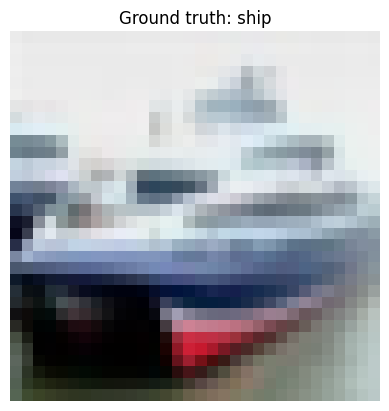

In [28]:
dataset_show_image(test_dset, 1)

## Training

### Training functions

In [29]:
def iterate(step_fn, loader):
    num_samples = 0
    total_loss = 0.
    num_correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss, out = step_fn(x, y)
        pred = out.argmax(axis=-1)
        correct = (pred == y)
        loss, correct = loss.cpu().numpy(), correct.cpu().numpy()
        num_samples += correct.shape[0]
        total_loss += loss
        num_correct += np.sum(correct)
    
    avg_loss = total_loss / num_samples
    acc = num_correct / num_samples
    metrics = {"loss": avg_loss, "acc": acc}
    return metrics

In [30]:
def train(model, loss_fn, optimizers, loader, batch_schedulers):
    def train_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)

        model.zero_grad(set_to_none=True)
        loss.backward()

        for opt, sched in zip(optimizers, batch_schedulers):
            opt.step()
            sched.step()
        return loss.detach(), out.detach()

    model.train()
    metrics = iterate(train_step, loader)
    return metrics

In [31]:
def evaluate(model, loss_fn, loader):
    def eval_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)
        return loss.detach(), out.detach()

    model.eval()
    with torch.inference_mode():
        metrics = iterate(eval_step, loader)
    return metrics

In [32]:
def update_history(history, metrics, name):
    for key, val in metrics.items():
        history[name + ' ' + key].append(val)

In [33]:
def history_plot_train_val(history, key):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    xs = np.arange(1, len(history['train ' + key]) + 1)
    ax.plot(xs, history['train ' + key], '.-', label='train')
    ax.plot(xs, history['val ' + key], '.-', label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel(key)
    ax.legend()
    ax.grid()
    plt.show()

### Start training

In [34]:
loss = nn.CrossEntropyLoss()

In [35]:
lr_scheduler1 = optim.lr_scheduler.OneCycleLR(optimizer1, max_lr=LEARNING_RATE,
                                              steps_per_epoch=len(train_loader), epochs=EPOCHS)

In [36]:
lr_scheduler2 = optim.lr_scheduler.OneCycleLR(optimizer2, max_lr=LEARNING_RATE,
                                              steps_per_epoch=len(train_loader), epochs=EPOCHS)

In [37]:
lr_schedulers = [lr_scheduler1, lr_scheduler2]

In [38]:
history = defaultdict(list)

In [39]:
pbar = trange(EPOCHS, ncols=140)
for epoch in pbar:
    train_metrics = train(model, loss, optimizers, train_loader, lr_schedulers)
    update_history(history, train_metrics, "train")
    
    val_metrics = evaluate(model, loss, test_loader)
    update_history(history, val_metrics, "val")
    pbar.set_postfix({"acc": train_metrics['acc'], "val acc": val_metrics['acc']})

100%|█████████████████████████████████████████████████████████████████████████| 100/100 [1:16:36<00:00, 45.97s/it, acc=0.907, val acc=0.929]


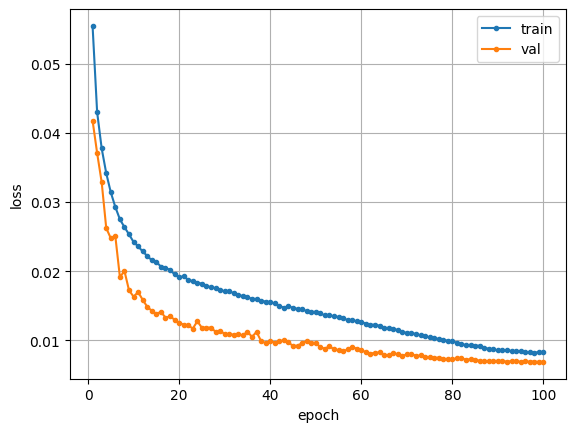

In [40]:
history_plot_train_val(history, 'loss')

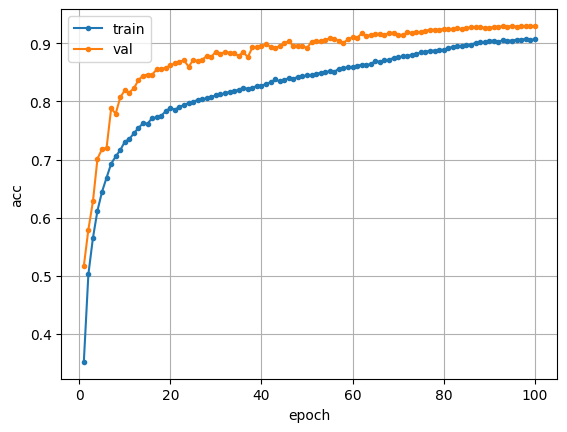

In [41]:
history_plot_train_val(history, 'acc')